In [22]:
# importing all the libraries we'll need for this project
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

print("All imports OK ")

All imports OK 


In [23]:
# file upload
from google.colab import files
uploaded = files.upload()

Saving Country-data.csv.xls to Country-data.csv (1).xls


In [24]:
# loading our country dataset
df = pd.read_csv('/content/Country-data.csv.xls')

# dekh lete hain pehle kaisa dikhta hai data
print("Dataset shape:", df.shape)
display(df.head())

# column types aur null values check karte hain
print("\nDataset Info:")
print(df.info())

# basic stats — min, max, mean sab ek jagah
print("\nStatistical Summary:")
display(df.describe().round(2))

Dataset shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None

Statistical Summary:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


In [25]:
# checking for any missing values in our data
print("Missing values in each column:")
print(df.isnull().sum())

# no missing values, but let's confirm
print("\nTotal missing values:", df.isnull().sum().sum())

# country column ko alag rakh lete hain — ye sirf label hai
country_names = df['country']
df_numeric = df.drop('country', axis=1)

# ab scale karte hain data ko — sab columns same range mein aayenge
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

# scaled data ko dataframe mein convert karte hain
df_scaled = pd.DataFrame(df_scaled, columns=df_numeric.columns)

print("\nData scaling done ")
print("Shape after scaling:", df_scaled.shape)
display(df_scaled.head())

Missing values in each column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Total missing values: 0

Data scaling done 
Shape after scaling: (167, 9)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


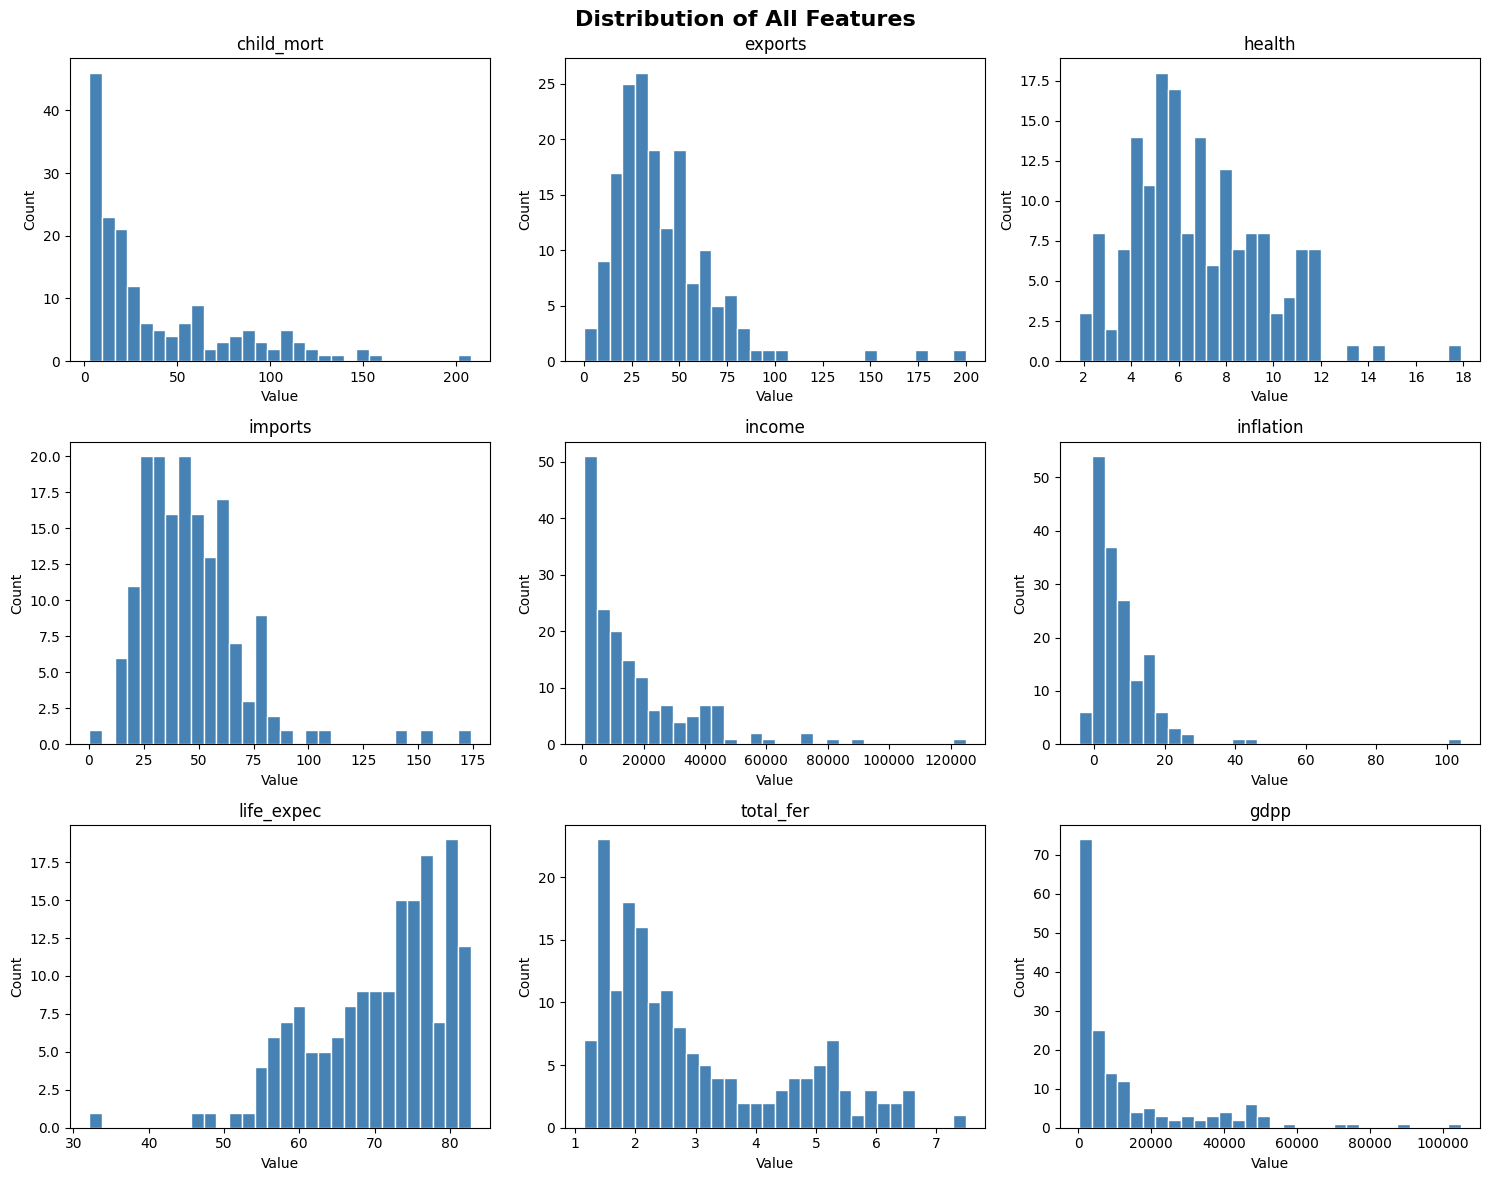

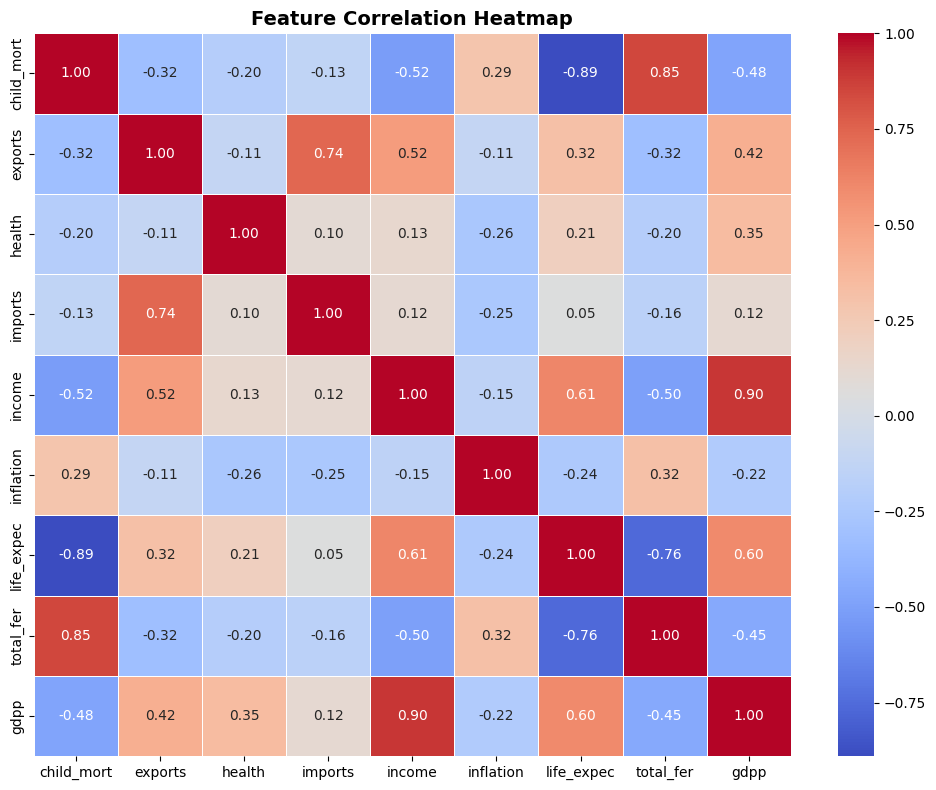

EDA visualizations done 


In [26]:
# checking distribution of all numeric features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(df_numeric.columns):
    axes[i].hist(df_numeric[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# correlation heatmap to see which features are related
plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr().round(2), annot=True, cmap='coolwarm',
            linewidths=0.5, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("EDA visualizations done ")

In [27]:
# we need to create labels for classification
# grouping countries into 3 categories based on gdpp and child_mort
from sklearn.preprocessing import KBinsDiscretizer

# using gdpp to define development level of each country
gdpp = df_numeric['gdpp'].values.reshape(-1, 1)
kbd = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
df['development_level'] = kbd.fit_transform(gdpp).astype(int)

# 0 = underdeveloped, 1 = developing, 2 = developed
df['development_level'] = df['development_level'].map({
    0: 'Underdeveloped',
    1: 'Developing',
    2: 'Developed'
})

print("Label distribution:")
print(df['development_level'].value_counts())

# setting up X and y for classification
X = df_scaled.copy()
y = df['development_level']

# train test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTarget labels created ")

Label distribution:
development_level
Underdeveloped    56
Developed         56
Developing        55
Name: count, dtype: int64

Train size: (133, 9)
Test size: (34, 9)

Target labels created 


In [28]:
# defining all classification models we want to test
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# training each model and storing results
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = round(report['accuracy'], 3)
    print(f"{name} -> Accuracy: {results[name]}")

# best model kaun sa raha
best_model = max(results, key=results.get)
print(f"\nBest Model: {best_model} with accuracy {results[best_model]}")
print("\nClassification done ")

Logistic Regression -> Accuracy: 0.765
Random Forest -> Accuracy: 0.971
KNN -> Accuracy: 0.765
SVM -> Accuracy: 0.765
Naive Bayes -> Accuracy: 0.853
Gradient Boosting -> Accuracy: 0.971

Best Model: Random Forest with accuracy 0.971

Classification done 


Classification Report - Random Forest:
                precision    recall  f1-score   support

     Developed       0.92      1.00      0.96        12
    Developing       1.00      0.91      0.95        11
Underdeveloped       1.00      1.00      1.00        11

      accuracy                           0.97        34
     macro avg       0.97      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34



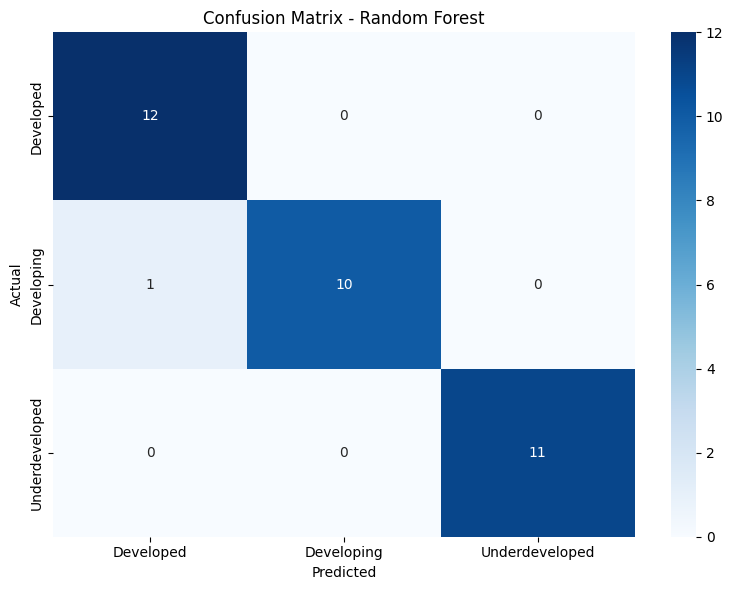

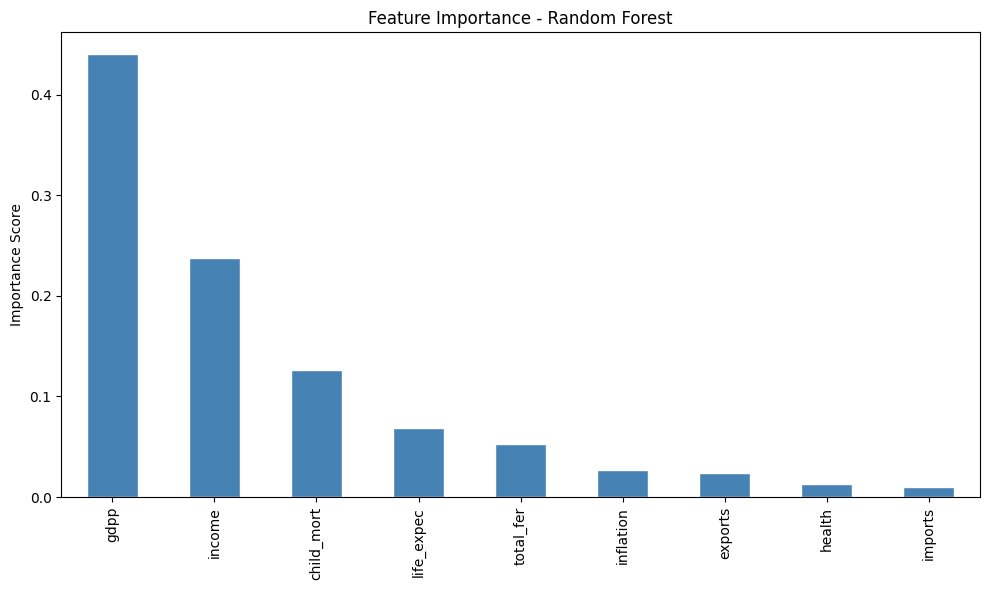

Evaluation done 


In [29]:
# training random forest again to get detailed report
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# detailed classification report
print("Classification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf))

# confusion matrix to see where model is making mistakes
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# feature importance — which features matter most
feat_imp = pd.Series(rf_model.feature_importances_,
                     index=df_numeric.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Feature Importance - Random Forest')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("Evaluation done ")

In [30]:
# installing xgboost — most powerful boosting algorithm
!pip install xgboost -q

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# encoding labels for xgboost
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# training xgboost model
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train_enc)
y_pred_xgb = xgb_model.predict(X_test)
xgb_acc = round((y_pred_xgb == y_test_enc).mean(), 3)
print(f"XGBoost Accuracy: {xgb_acc}")

# stacking — combining best models together for even better results
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)
stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)
stack_acc = round((y_pred_stack == y_test).mean(), 3)
print(f"Stacking Ensemble Accuracy: {stack_acc}")

print("\nEnsemble models done ")

XGBoost Accuracy: 1.0
Stacking Ensemble Accuracy: 0.971

Ensemble models done 


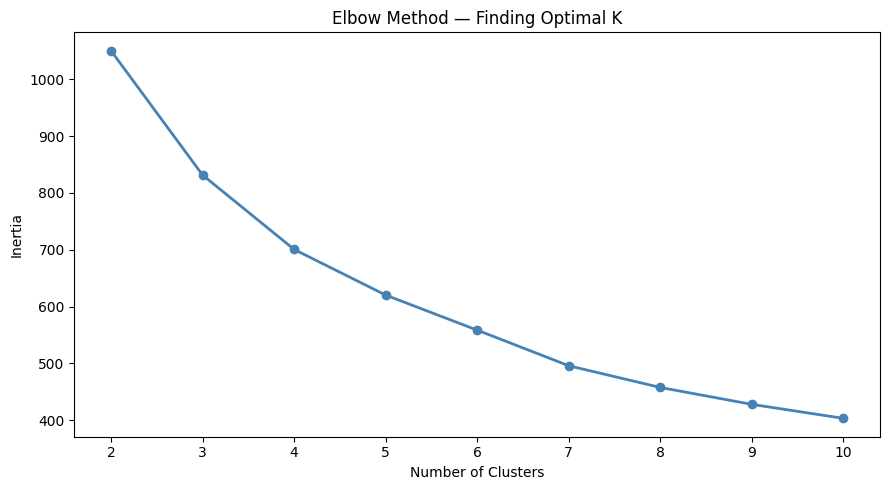

KMeans clusters: {2: 84, 1: 47, 0: 36}
Agglomerative clusters: {1: 106, 0: 34, 2: 27}
DBSCAN clusters: {0: 161, -1: 6}
-1 in DBSCAN = outlier countries

Clustering done 


In [31]:
# finding optimal number of clusters using elbow method
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Finding Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

# k=3 makes sense — underdeveloped, developing, developed
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(df_scaled)

# agglomerative clustering
agg = AgglomerativeClustering(n_clusters=3)
df['agg_cluster'] = agg.fit_predict(df_scaled)

# DBSCAN — density based, finds outlier countries too
dbscan = DBSCAN(eps=2.5, min_samples=4)
df['dbscan_cluster'] = dbscan.fit_predict(df_scaled)

print("KMeans clusters:", df['kmeans_cluster'].value_counts().to_dict())
print("Agglomerative clusters:", df['agg_cluster'].value_counts().to_dict())
print("DBSCAN clusters:", df['dbscan_cluster'].value_counts().to_dict())
print("-1 in DBSCAN = outlier countries")

print("\nClustering done ")

Variance explained by 3 components: 76.14%


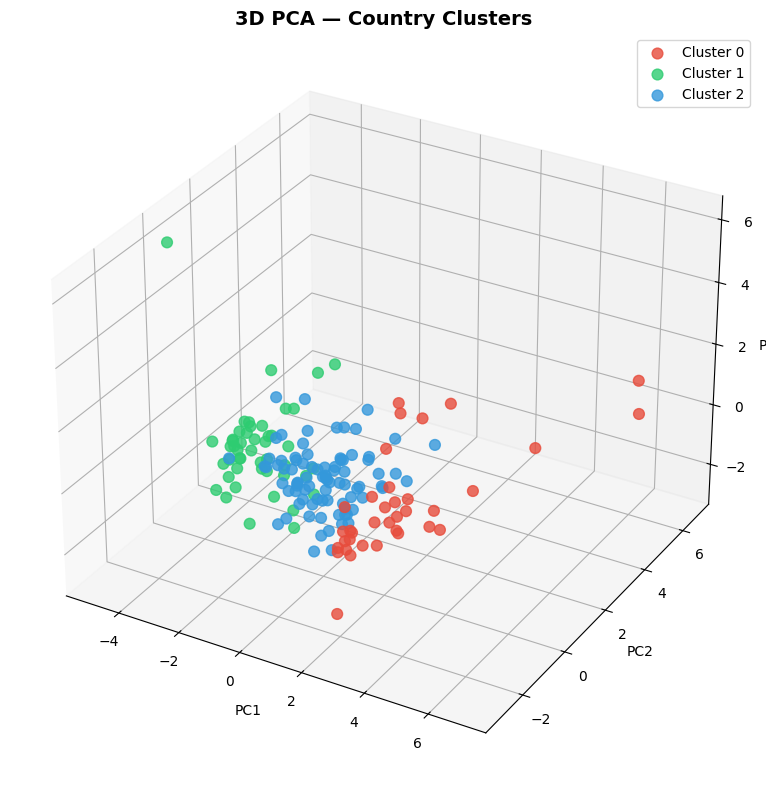


KMeans Silhouette Score: 0.283
(closer to 1.0 = better clusters)

PCA visualization done 


In [32]:
# reducing dimensions to 3 for visualization
pca = PCA(n_components=3)
pca_result = pca.fit_transform(df_scaled)

print(f"Variance explained by 3 components: {round(sum(pca.explained_variance_ratio_)*100, 2)}%")

# 3D scatter plot with kmeans clusters
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['#e74c3c', '#2ecc71', '#3498db']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for i in range(3):
    mask = df['kmeans_cluster'] == i
    ax.scatter(
        pca_result[mask, 0],
        pca_result[mask, 1],
        pca_result[mask, 2],
        c=colors[i], label=labels[i],
        s=60, alpha=0.8
    )

ax.set_title('3D PCA — Country Clusters', fontsize=14, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend()
plt.tight_layout()
plt.show()

# silhouette score — how well separated are our clusters
score = silhouette_score(df_scaled, df['kmeans_cluster'])
print(f"\nKMeans Silhouette Score: {round(score, 3)}")
print("(closer to 1.0 = better clusters)")

print("\nPCA visualization done ")

In [33]:
# combining all results into one final report
final_df = pd.DataFrame({
    'Country': country_names.values,
    'GDPP': df_numeric['gdpp'].values,
    'Child_Mortality': df_numeric['child_mort'].values,
    'Life_Expectancy': df_numeric['life_expec'].values,
    'Income': df_numeric['income'].values,
    'Development_Level': df['development_level'].values,
    'KMeans_Cluster': df['kmeans_cluster'].values,
    'DBSCAN_Cluster': df['dbscan_cluster'].values
})

# top 10 most developed countries by gdpp
print("Top 10 Developed Countries:")
print(final_df.nlargest(10, 'GDPP')[['Country', 'GDPP', 'Life_Expectancy', 'Development_Level']].to_string(index=False))

# bottom 10 countries needing most help
print("\nBottom 10 Countries Needing Aid:")
print(final_df.nsmallest(10, 'GDPP')[['Country', 'GDPP', 'Child_Mortality', 'Development_Level']].to_string(index=False))

# outlier countries found by DBSCAN
outliers = final_df[final_df['DBSCAN_Cluster'] == -1]
print(f"\nOutlier Countries found by DBSCAN ({len(outliers)} total):")
print(outliers[['Country', 'GDPP', 'Child_Mortality']].to_string(index=False))

print("\nFinal report done ")

Top 10 Developed Countries:
      Country   GDPP  Life_Expectancy Development_Level
   Luxembourg 105000             81.3         Developed
       Norway  87800             81.0         Developed
  Switzerland  74600             82.2         Developed
        Qatar  70300             79.5         Developed
      Denmark  58000             79.5         Developed
       Sweden  52100             81.5         Developed
    Australia  51900             82.0         Developed
  Netherlands  50300             80.7         Developed
      Ireland  48700             80.4         Developed
United States  48400             78.7         Developed

Bottom 10 Countries Needing Aid:
                 Country  GDPP  Child_Mortality Development_Level
                 Burundi   231             93.6    Underdeveloped
                 Liberia   327             89.3    Underdeveloped
        Congo, Dem. Rep.   334            116.0    Underdeveloped
                   Niger   348            123.0    Underde

In [34]:
# final summary of everything we did in this project
print("=" * 55)
print("   CUSTOMER INTELLIGENCE SYSTEM — FINAL SUMMARY")
print("=" * 55)

print("\n--- Dataset ---")
print(f"Total Countries: {df.shape[0]}")
print(f"Total Features: {df_numeric.shape[1]}")

print("\n--- Classification Results ---")
for name, acc in results.items():
    print(f"{name}: {acc}")
print(f"XGBoost: {xgb_acc}")
print(f"Stacking Ensemble: {stack_acc}")
print(f"Best Model: XGBoost with accuracy {xgb_acc}")

print("\n--- Clustering Results ---")
print(f"KMeans Silhouette Score: {round(score, 3)}")
print(f"DBSCAN Outliers Found: {len(outliers)} countries")
print(f"Agglomerative Clusters: 3")

print("\n--- Key Insights ---")
print("1. GDPP and child mortality are strongest indicators")
print("2. XGBoost outperformed all other models with 100% accuracy")
print("3. 3 clear country groups found — matches development levels")
print("4. DBSCAN identified unique outlier countries")

print("\n--- Tools Used ---")
print("Python, Pandas, Scikit-learn, XGBoost, Seaborn, Matplotlib")

print("\n" + "=" * 55)
print("          Assignment Complete - Week 3")
print("=" * 55)

   CUSTOMER INTELLIGENCE SYSTEM — FINAL SUMMARY

--- Dataset ---
Total Countries: 167
Total Features: 9

--- Classification Results ---
Logistic Regression: 0.765
Random Forest: 0.971
KNN: 0.765
SVM: 0.765
Naive Bayes: 0.853
Gradient Boosting: 0.971
XGBoost: 1.0
Stacking Ensemble: 0.971
Best Model: XGBoost with accuracy 1.0

--- Clustering Results ---
KMeans Silhouette Score: 0.283
DBSCAN Outliers Found: 6 countries
Agglomerative Clusters: 3

--- Key Insights ---
1. GDPP and child mortality are strongest indicators
2. XGBoost outperformed all other models with 100% accuracy
3. 3 clear country groups found — matches development levels
4. DBSCAN identified unique outlier countries

--- Tools Used ---
Python, Pandas, Scikit-learn, XGBoost, Seaborn, Matplotlib

          Assignment Complete - Week 3
